# MSA vs Jordanian Pointer Networks

Loaded environment variables from: /home/eman/signly/.env

 STARTING PIPELINE FOR VARIANT: MSA 
[!] Training new MSA model variation...
Epoch [00/79] -> Train Loss: 1.8172 | Val Loss: 1.6318 | Patience: 0/10
Epoch [10/79] -> Train Loss: 0.1964 | Val Loss: 0.2698 | Patience: 0/10
Epoch [20/79] -> Train Loss: 0.0819 | Val Loss: 0.2311 | Patience: 2/10
Epoch [28/79] -> Train Loss: 0.0232 | Val Loss: 0.2015 | Patience: 10/10

[!] Early stopping triggered at epoch 28!
Saved MSA checkpoint to: /home/eman/signly/data/supa_corpus_det/pointer_net_msa.pth

Inference Running on 63 Aligned Test Sequences (MSA)
Example 1:
Source (NLP) : قبل أخبر صديق كتاب مفيد
Target (ArSL): صديق كتاب مفيد قبل أخبر
Prediction   : صديق كتاب مفيد قبل أخبر
--------------------------------------------------
Example 2:
Source (NLP) : رايت كثير مفتاح
Target (ArSL): رايت مفتاح كثير
Prediction   : مفتاح رايت كثير
--------------------------------------------------
Example 3:
Source (NLP) : أن ولد جائع قبل طلب طالب طعام
Targ

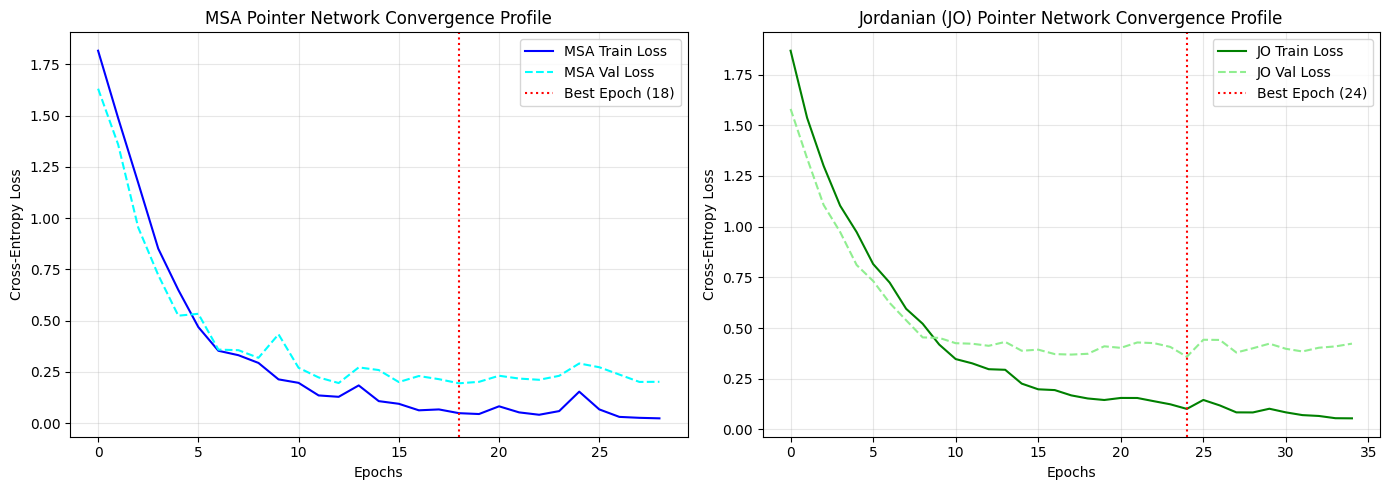


               MANUAL INFERENCE TERMINAL (JO)               
Type an Arabic sentence to test the model.
Type 'q' or 'quit' to exit.

transform_to_arsl received: 'صاحبي قبل قال الان ذهب مدرسة'
NLP Tokens  : اثنان صاحب قبل قبل قال آن قبل ذهب مدرسة
ArSL Output : صاحب اثنان قال قبل ذهب مدرسة قبل قبل آن

transform_to_arsl received: 'صاحبي قال نروح عالمدرسة'
NLP Tokens  : اثنان صاحب قبل قال كثير الان راح عالمدرسه
ArSL Output : صاحب اثنان قال كثير الان قبل راح عالمدرسه

transform_to_arsl received: 'البنتين قرأتا الكتاب'
NLP Tokens  : اثنان بنت قبل قرأ كتاب
ArSL Output : بنت اثنان كتاب قبل قرأ

transform_to_arsl received: 'البنتين قرؤوا الكتاب'
NLP Tokens  : اثنان بنت كثير قبل قرأ كتاب
ArSL Output : بنت اثنان كثير كتاب قبل قرأ

transform_to_arsl received: 'كيف حالك'
NLP Tokens  : حال كيف
ArSL Output : حال كيف

transform_to_arsl received: 'ما بعرف'
NLP Tokens  : عرف
ArSL Output : عرف

transform_to_arsl received: 'مش ممكن'
NLP Tokens  : مش ممكن
ArSL Output : مش ممكن

transform_to_arsl received:

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from scipy import stats
import sys
from dotenv import load_dotenv
from collections import Counter

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')
env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"Loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"Loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

try:
    from app.core.nlp_utils import transform_to_arsl
except ImportError:
    print("[Warning] Could not import 'transform_to_arsl' from app.core.nlp_utils.")
    print("Placeholder function assigned to avoid runtime failure.")
    def transform_to_arsl(text):
        return text.split()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20
NUM_EPOCHS = 80

WEIGHT_DECAY = 1e-4  # L2
DROPOUT_RATE = 0.3   
PATIENCE = 10

FORCE_RETRAIN = True  # False will load checkpoint instead of training

DATA_DIR = os.path.join(root_dir, 'data', 'supa_corpus_det')
PATH_MASTER_NLP_OUT = os.path.join(DATA_DIR, 'jo_og_nlp_processed.txt')
PATH_MASTER_TARGET = os.path.join(DATA_DIR, 'jo_targets.txt')

MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'pointer_net_weights.pth')

PATH_MSA_WEIGHTS = os.path.join(DATA_DIR, 'pointer_net_msa.pth') # for extracting comparative visualizations
PATH_JO_WEIGHTS = os.path.join(DATA_DIR, 'pointer_net_jo.pth')

def split_master_dataset(src_path, tgt_path, out_paths, train_ratio=0.8, val_ratio=0.1):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        print(f"Skipping dataset split: Master files not found for {src_path}")
        return
        
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
        
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"):
                clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)

    assert len(src_lines) == len(tgt_lines), f"Lines mismatch! Source: {len(src_lines)}, Target: {len(tgt_lines)}"
    total_lines = len(src_lines)
    
    combined = list(zip(src_lines, tgt_lines))
    random.seed(42) 
    random.shuffle(combined)
    src_lines_shuffled, tgt_lines_shuffled = zip(*combined)

    train_end = int(total_lines * train_ratio)
    val_end = train_end + int(total_lines * val_ratio)

    splits = {
        'train': (src_lines_shuffled[:train_end], tgt_lines_shuffled[:train_end], out_paths['train_src'], out_paths['train_tgt']),
        'val': (src_lines_shuffled[train_end:val_end], tgt_lines_shuffled[train_end:val_end], out_paths['val_src'], out_paths['val_tgt']),
        'test': (src_lines_shuffled[val_end:], tgt_lines_shuffled[val_end:], out_paths['test_src'], out_paths['test_tgt'])
    }

    for split_name, (src_data, tgt_data, src_out_path, tgt_out_path) in splits.items():
        with open(src_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(src_data) + '\n')
        with open(tgt_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(tgt_data) + '\n')


def load_aligned_data(src_path, tgt_path):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        return [], []
    with open(src_path, 'r', encoding='utf-8') as f: src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"): clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)
    return src_lines, tgt_lines


class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        target_indices = []
        for word in target_words:
            if word in source_words: target_indices.append(source_words.index(word))
            else: target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)


class PointerAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores


class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)
        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x = self.dropout(x)
        enc_out, (h_n, c_n) = self.encoder(x)
        enc_out = self.dropout(enc_out)

        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]
        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            h_d_dropped = self.dropout(h_d)
            logits = self.attention(h_d_dropped.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1)


def plot_convergence(history, best_epoch_idx):
    """Plots single-model convergence metrics."""
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
    
    if best_epoch_idx >= 0:
        plt.axvline(x=best_epoch_idx, color='r', linestyle=':', label='Best Epoch (Restored)')
        
    plt.title("Pointer Network: Convergence Profile")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def train_and_validate(train_loader, val_loader, patience=PATIENCE):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1 or patience_counter >= patience:
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at epoch {epoch}!")
            break
     
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        
    best_epoch_idx = len(history['val_loss']) - patience_counter - 1
    
    return model, history, best_epoch_idx


def compute_bootstrap_ci(metrics_list, confidence=0.95, n_resamples=1000):
    if not metrics_list: return 0.0, 0.0, 0.0
    means = []
    for _ in range(n_resamples):
        sample = random.choices(metrics_list, k=len(metrics_list))
        means.append(np.mean(sample))
    lower = np.percentile(means, ((1 - confidence) / 2) * 100)
    upper = np.percentile(means, (1 - (1 - confidence) / 2) * 100)
    return np.mean(metrics_list), lower, upper


def compute_wer(reference_words, predicted_words):
    if not reference_words: return 1.0
    d = np.zeros((len(reference_words) + 1, len(predicted_words) + 1))
    for i in range(len(reference_words) + 1): d[i, 0] = i
    for j in range(len(predicted_words) + 1): d[0, j] = j
    
    for i in range(1, len(reference_words) + 1):
        for j in range(1, len(predicted_words) + 1):
            cost = 0 if reference_words[i - 1] == predicted_words[j - 1] else 1
            d[i, j] = min(
                d[i - 1, j] + 1,        
                d[i, j - 1] + 1,        
                d[i - 1, j - 1] + cost   
            )
    return d[len(reference_words), len(predicted_words)] / len(reference_words)


def compute_per(reference_words, predicted_words):
    if not reference_words: return 1.0
    ref_counts = Counter(reference_words)
    pred_counts = Counter(predicted_words)
    overlap = sum((ref_counts & pred_counts).values())
    deletions = len(reference_words) - overlap
    insertions = len(predicted_words) - overlap
    return (deletions + insertions) / len(reference_words)


def evaluate_on_test_set(model, src_lines, tgt_lines, variant_name):
    if not src_lines:
        print("Test sequence empty. Skipping test set evaluation.")
        return
        
    model.eval()
    smooth_fn = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    bleu_scores, rouge_scores, exact_matches, kendall_taus = [], [], [], []
    wer_scores, per_scores = [], []

    print(f"\nInference Running on {len(src_lines)} Aligned Test Sequences ({variant_name})")
    inspection_path = os.path.join(root_dir, f'predictions_inspection_{variant_name.lower()}.txt')
    inspection_file = open(inspection_path, "w", encoding="utf-8")
    
    with torch.no_grad():
        for i, (src_sent, tgt_sent) in enumerate(zip(src_lines, tgt_lines)):
            src_words = src_sent.split()[:MAX_LEN]
            n = len(src_words)
            if n == 0: continue
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            logits = model(padded_x)[0]

            indices = []
            mask = torch.zeros(n).to(DEVICE)
            for step in range(n):
                step_logits = logits[step, :n] + mask
                idx = torch.argmax(step_logits).item()
                indices.append(idx)
                mask[idx] = -1e9

            predicted_words = [src_words[idx] for idx in indices]
            pred_sent = " ".join(predicted_words)
            ref_words = tgt_sent.split()
            
            log_text = (
                f"Example {i+1}:\n"
                f"Source (NLP) : {src_sent}\n"
                f"Target (ArSL): {tgt_sent}\n"
                f"Prediction   : {pred_sent}\n"
                f"{'-'*50}\n"
            )
            inspection_file.write(log_text)
            if i < 3: print(log_text.strip())

            b_score = sentence_bleu([ref_words], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
            r_score = scorer.score(tgt_sent, pred_sent)['rougeL'].fmeasure
            em_score = 1.0 if pred_sent.strip() == tgt_sent.strip() else 0.0
            wer_score = compute_wer(ref_words, predicted_words)
            per_score = compute_per(ref_words, predicted_words)

            target_idx = []
            valid_permutation = True
            for w in ref_words:
                if w in src_words: target_idx.append(src_words.index(w))
                else: valid_permutation = False; break
                
            if valid_permutation and len(target_idx) == len(indices):
                tau, _ = stats.kendalltau(target_idx, indices)
                if not np.isnan(tau): kendall_taus.append(max(0, tau))

            bleu_scores.append(b_score)
            rouge_scores.append(r_score)
            exact_matches.append(em_score)
            wer_scores.append(wer_score)
            per_scores.append(per_score)

    inspection_file.close()
    
    m_bleu, b_l, b_h = compute_bootstrap_ci(bleu_scores)
    m_rouge, r_l, r_h = compute_bootstrap_ci(rouge_scores)
    m_em, em_l, em_h = compute_bootstrap_ci(exact_matches)
    m_tau, tau_l, tau_h = compute_bootstrap_ci(kendall_taus)
    m_wer, wer_l, wer_h = compute_bootstrap_ci(wer_scores)
    m_per, per_l, per_h = compute_bootstrap_ci(per_scores)

    print("\n" + "="*65)
    print(f"{f'{variant_name} EVALUATION METRICS':^65}")
    print("="*65)
    print(f"{'Metric':<25} | {'Mean Value':<12} | {'95% Confidence Interval (CI)':<30}")
    print("-"*65)
    print(f"{'Exact Match':<25} | {m_em*100:<12.2f}% | [{em_l*100:.2f}%, {em_h*100:.2f}%]")
    print(f"{'BLEU-4':<25} | {m_bleu*100:<12.2f}% | [{b_l*100:.2f}%, {b_h*100:.2f}%]")
    print(f"{'ROUGE-L':<25} | {m_rouge*100:<12.2f}% | [{r_l*100:.2f}%, {r_h*100:.2f}%]")
    print(f"{'Kendall Tau':<25} | {m_tau*100:<12.2f}% | [{tau_l*100:.2f}%, {tau_h*100:.2f}%]")
    print(f"{'WER (Lower is better)':<25} | {m_wer*100:<12.2f}% | [{wer_l*100:.2f}%, {wer_h*100:.2f}%]")
    print(f"{'PER (Lower is better)':<25} | {m_per*100:<12.2f}% | [{per_l*100:.2f}%, {per_h*100:.2f}%]")
    print("="*65 + "\n")


def test_manual_sentences(model):
    print("\n" + "="*60)
    print(f"{'MANUAL INFERENCE TERMINAL (JO)':^60}")
    print("="*60)
    print("Type an Arabic sentence to test the model.")
    print("Type 'q' or 'quit' to exit.\n")
    
    model.eval()
    while True:
        user_input = input(">> Enter Arabic Text: ").strip()
        if user_input.lower() in ['q', 'quit', 'exit']:
            break
        if not user_input:
            continue
            
        try:
            processed_words = transform_to_arsl(user_input)
            if not processed_words:
                print("NLP Pipeline returned empty list.\n")
                continue
                
            src_words = processed_words[:MAX_LEN]
            n = len(src_words)
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            
            with torch.no_grad():
                logits = model(padded_x)[0]
                indices = []
                mask = torch.zeros(n).to(DEVICE)
                for step in range(n):
                    step_logits = logits[step, :n] + mask
                    idx = torch.argmax(step_logits).item()
                    indices.append(idx)
                    mask[idx] = -1e9
                    
            predicted_words = [src_words[idx] for idx in indices]
            print(f"NLP Tokens  : {' '.join(src_words)}")
            print(f"ArSL Output : {' '.join(predicted_words)}\n")
            
        except Exception as e:
            print(f"Error processing input: {e}\n")


def plot_model_comparisons(path_msa, path_jo):
    if not os.path.exists(path_msa) or not os.path.exists(path_jo):
        print("\n[Notice] Could not find both MSA and JO .pth checkpoints to render comparative plots.")
        return

    checkpoint_msa = torch.load(path_msa, map_location=torch.device('cpu'))
    checkpoint_jo = torch.load(path_jo, map_location=torch.device('cpu'))

    hist_msa = checkpoint_msa['history']
    hist_jo = checkpoint_jo['history']
    best_ep_msa = checkpoint_msa.get('best_epoch_idx', -1)
    best_ep_jo = checkpoint_jo.get('best_epoch_idx', -1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # MSA Subplot
    ax1.plot(hist_msa['train_loss'], label='MSA Train Loss', color='blue', lw=1.5)
    ax1.plot(hist_msa['val_loss'], label='MSA Val Loss', color='cyan', linestyle='--', lw=1.5)
    if best_ep_msa >= 0:
        ax1.axvline(x=best_ep_msa, color='red', linestyle=':', label=f'Best Epoch ({best_ep_msa})')
    ax1.set_title("MSA Pointer Network Convergence Profile")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # JO Subplot
    ax2.plot(hist_jo['train_loss'], label='JO Train Loss', color='green', lw=1.5)
    ax2.plot(hist_jo['val_loss'], label='JO Val Loss', color='lightgreen', linestyle='--', lw=1.5)
    if best_ep_jo >= 0:
        ax2.axvline(x=best_ep_jo, color='red', linestyle=':', label=f'Best Epoch ({best_ep_jo})')
    ax2.set_title("Jordanian (JO) Pointer Network Convergence Profile")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    
    variants = {
        'MSA': {
            'src_master': os.path.join(DATA_DIR, 'msa_og_nlp_processed.txt'), 
            'tgt_master': os.path.join(DATA_DIR, 'msa_targets.txt'),      
            'weight_path': PATH_MSA_WEIGHTS,
            'splits': {
                'train_src': os.path.join(DATA_DIR, 'msa_train.txt'),
                'train_tgt': os.path.join(DATA_DIR, 'msa_train-targets.txt'),
                'val_src': os.path.join(DATA_DIR, 'msa_val.txt'),
                'val_tgt': os.path.join(DATA_DIR, 'msa_val-targets.txt'),
                'test_src': os.path.join(DATA_DIR, 'msa_test.txt'),
                'test_tgt': os.path.join(DATA_DIR, 'msa_test-targets.txt'),
            }
        },
        'JO': {
            'src_master': PATH_MASTER_NLP_OUT,
            'tgt_master': PATH_MASTER_TARGET,
            'weight_path': PATH_JO_WEIGHTS,
            'splits': {
                'train_src': os.path.join(DATA_DIR, 'jo_train.txt'),
                'train_tgt': os.path.join(DATA_DIR, 'jo_train-targets.txt'),
                'val_src': os.path.join(DATA_DIR, 'jo_val.txt'),
                'val_tgt': os.path.join(DATA_DIR, 'jo_val-targets.txt'),
                'test_src': os.path.join(DATA_DIR, 'jo_test.txt'),
                'test_tgt': os.path.join(DATA_DIR, 'jo_test-targets.txt'),
            }
        }
    }
    
    trained_models = {}

    for name, config in variants.items():
        print("\n" + "="*60)
        print(f" STARTING PIPELINE FOR VARIANT: {name} ")
        print("="*60)
        
        split_master_dataset(config['src_master'], config['tgt_master'], config['splits'])
        
        train_src_lines, train_tgt_lines = load_aligned_data(config['splits']['train_src'], config['splits']['train_tgt'])
        val_src_lines, val_tgt_lines = load_aligned_data(config['splits']['val_src'], config['splits']['val_tgt'])
        test_src_lines, test_tgt_lines = load_aligned_data(config['splits']['test_src'], config['splits']['test_tgt'])
        
        model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
        
        if os.path.exists(config['weight_path']) and not FORCE_RETRAIN:
            print(f"[!] Loading existing {name} weights from {config['weight_path']}...")
            checkpoint = torch.load(config['weight_path'], map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state'])
        else:
            print(f"[!] Training new {name} model variation...")
            train_ds = PointerDataset(train_src_lines, train_tgt_lines)
            val_ds = PointerDataset(val_src_lines, val_tgt_lines)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

            model, history, best_epoch_idx = train_and_validate(train_loader, val_loader)
            
            torch.save({
                'model_state': model.state_dict(),
                'history': history,
                'best_epoch_idx': best_epoch_idx
            }, config['weight_path'])
            print(f"Saved {name} checkpoint to: {config['weight_path']}")
            
        evaluate_on_test_set(model, test_src_lines, test_tgt_lines, name)
        trained_models[name] = model

    print("\n[!] Rendering comparative loss visualization curves...")
    plot_model_comparisons(PATH_MSA_WEIGHTS, PATH_JO_WEIGHTS)

    test_manual_sentences(trained_models['JO'])

# Training Data Preprocessing (Via nlp_utils)

In [ ]:
import os, sys
from dotenv import load_dotenv

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')

env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

from app.core.nlp_utils import transform_to_arsl

def preprocess_file(source_path, dest_path):
    """Processes raw Arabic text through the NLP pipeline and saves it."""
    if not os.path.exists(source_path):
        print(f"Warning: Source text file not found at: {source_path}. Skipping preprocessing.")
        return
        
    print(f"Processing {source_path} through nlp_utils")
    processed_lines = []
    with open(source_path, 'r', encoding='utf-8') as f:
        raw_lines = [line.strip() for line in f if line.strip()]
        
    for idx, line in enumerate(raw_lines):
        gloss_list = transform_to_arsl(line)
        processed_line = " ".join(gloss_list)
        processed_lines.append(processed_line)
        
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    with open(dest_path, 'w', encoding='utf-8') as f:
        for line in processed_lines:
            f.write(line + "\n")
            
    print(f"Saved pipeline outputs to: {dest_path}\n")
    
preprocess_file(r'signly/data/supa_corpus_det/jo_og.txt', 'signly/data/supa_corpus_det/jo_og_nlp_processed.txt')

loaded environment variables from: /home/eman/signly/.env
Processing /home/eman/signly/data/supa_corpus_det/jo_og.txt through nlp_utils
transform_to_arsl received: 'الأستاذ اشترى بسكليت جديد أحمر'
transform_to_arsl received: 'اشترى الأستاذ بسكليت أحمر جديد'
transform_to_arsl received: 'كتب الزلمة درس صعب ممتع'
transform_to_arsl received: 'طلب الولد اللبن'
transform_to_arsl received: 'طلب الطالب اللبن'
transform_to_arsl received: 'بياكل الولد التفاح'
transform_to_arsl received: 'الزلمة حفظ دفتر قديم صعب'
transform_to_arsl received: 'الولد نام بعدين الزلمة نام'
transform_to_arsl received: 'أخوي أكل بعدين الموظف شرب'
transform_to_arsl received: 'الولد حفظ درس ممتع قديم'
transform_to_arsl received: 'التفاح أكل الطفل'
transform_to_arsl received: 'امبارح بيغادر الولد الجامعة'
transform_to_arsl received: 'صاحبي طلب الشاي'
transform_to_arsl received: 'الولد شرب العصير لأنه الجو حلو'
transform_to_arsl received: 'حفظ صاحبي دفتر صعب مفيد'
transform_to_arsl received: 'باع الولد بسكليت أحمر سريع'
t